# Validation statistique complémentaire du Vehicle Health Score

---

> **Notebook de validation statistique — Module VHS**
> **Profil analysé :** `VHS_BALANCED_V3_CANDIDATE`
> **Date :** 2026-07-04
> **Destinataires :** BNA Assurances, encadrement académique, jury technique

---

## Objectif

Ce notebook réalise la **couche de validation statistique complémentaire** du module VHS, conformément au plan méthodologique défini dans `docs/vhs/vhs_statistical_robustness_plan.md`.

Le VHS est un **score déterministe à base de règles métier**. Les méthodes statistiques présentées ici ne le remplacent pas — elles servent à **challenger**, **valider** et **stabiliser** le score existant en testant sa cohérence, sa robustesse et sa stabilité.

> **"La base PostgreSQL/DWH constitue la source de vérité du projet ; ce notebook extrait les données en lecture seule afin de produire des analyses statistiques sans modifier le moteur VHS ni les tables existantes."**

## Contraintes de sécurité

- **Lecture seule :** uniquement des requêtes `SELECT`. Toute requête DML/DDL lève une `ValueError`.
- **Moteur VHS intact :** `etl/mart/compute_vhs_v3_candidate.py` n'est pas modifié.
- **Aucune écriture en base :** aucun `INSERT`, `UPDATE`, `DELETE`, `CREATE TABLE` ni `ALTER`.
- **SHAP non applicable :** le VHS est déterministe, SHAP est réservé aux futurs modèles ML.
- **XGBoost non utilisé :** les méthodes arbre/clustering/PCA sont des outils d'audit uniquement.

In [19]:
import re

def assert_read_only_sql(query: str) -> None:
    '''Lève ValueError si la requête contient un mot-clé DML/DDL interdit.'''
    q = re.sub(r'--[^\n]*', '', query)
    q = re.sub(r'/\*.*?\*/', '', q, flags=re.DOTALL)
    q_lower = q.lower()
    forbidden = ['insert', 'update', 'delete', 'drop', 'alter',
                 'create', 'truncate', 'merge', 'grant', 'revoke']
    for kw in forbidden:
        if re.search(r'\b' + kw + r'\b', q_lower):
            raise ValueError(
                f"[SÉCURITÉ] Mot-clé interdit '{kw.upper()}' détecté. "
                "Seules les requêtes SELECT sont autorisées dans ce notebook."
            )

# Self-test
_safe_tests = [
    'SELECT 1',
    'SELECT * FROM mart.fact_vhs_score WHERE profile_name = :p',
    'SELECT table_name FROM information_schema.tables',
]
_block_tests = [
    "INSERT INTO foo VALUES (1)",
    "DROP TABLE mart.fact_vhs_score",
    "UPDATE fact_vhs_score SET score = 0",
    "CREATE TABLE hack (id INT)",
]
for _q in _safe_tests:
    try:
        assert_read_only_sql(_q)
    except ValueError as e:
        print(f'[ERROR] Safe query incorrectly blocked: {_q}')

for _q in _block_tests:
    try:
        assert_read_only_sql(_q)
        print(f'[ERROR] Dangerous query not blocked: {_q}')
    except ValueError:
        pass  # expected

print('READ-ONLY MODE ENABLED — SELECT queries only.')
print('[OK] assert_read_only_sql opérationnelle — 3 requêtes sûres validées, 4 DML bloquées.')

READ-ONLY MODE ENABLED — SELECT queries only.
[OK] assert_read_only_sql opérationnelle — 3 requêtes sûres validées, 4 DML bloquées.


In [20]:
import sys
import warnings
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['figure.facecolor'] = 'white'

# -- sklearn (optional)
try:
    from sklearn.tree import DecisionTreeClassifier, export_text
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA as SklearnPCA
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import accuracy_score
    SKLEARN_AVAILABLE = True
    print('[OK] sklearn disponible (arbre / clustering / PCA actifs).')
except ImportError:
    SKLEARN_AVAILABLE = False
    print('[INFO] sklearn non disponible — sections arbre/clustering/PCA ignorées.')

# -- scipy (optional)
try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
    print('[OK] scipy disponible (corrélation de Spearman active).')
except ImportError:
    SCIPY_AVAILABLE = False
    print('[INFO] scipy non disponible — Spearman ignoré.')

# -- Project root detection
_p = Path.cwd()
PROJECT_ROOT = None
for _ in range(6):
    if (_p / 'etl' / 'mart' / 'compute_vhs_v3_candidate.py').exists():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    _fb = Path('c:/Users/wiem/Downloads/Projet PFE/IRIS_AUTO_FRAUD')
    if _fb.exists():
        PROJECT_ROOT = _fb
assert PROJECT_ROOT is not None, 'Project root introuvable.'

PROFILE_NAME        = 'VHS_BALANCED_V3_CANDIDATE'
VALIDATED_RUN_ID    = 'VHS_BALANCED_V3_CANDIDATE_20260703_181257'
VALIDATED_RUN_ALT   = 'VHS_BALANCED_V3_CANDIDATE_20260703_181530'
N_BOOTSTRAP         = 1000
RANDOM_STATE        = 42

# -- Documented reference values (from validated run reports)
DOCUMENTED = {
    'run_id':               VALIDATED_RUN_ALT,
    'n_inspections':        286,
    'n_penalty_rows':       9724,
    'score_avg':            56.46,
    'score_min':            0.0,
    'score_max':            100.0,
    'decision':  {'OK': 89, 'DEGRADE': 133, 'IMMOBILISE': 13, 'CRITIQUE': 51},
    'grade':     {'A': 95,  'B': 11,   'C': 129, 'D': 51},
    'status':    {'OK': 8538, 'WORN': 389, 'WORN_STRONG': 283,
                  'BROKEN': 502, 'REPAIRED': 12, 'UNKNOWN': 0},
    'proposition_to_broken': 0,
    'non_to_broken':         0,
}

DECISION_LABELS = {
    'OK':        'État satisfaisant',
    'DEGRADE':   'État à surveiller',
    'IMMOBILISE':'Usage déconseillé',
    'CRITIQUE':  'Examen prioritaire suggéré',
}
STATUS_LABELS = {
    'OK':         'Élément conforme',
    'WORN':       'Usure observée',
    'WORN_STRONG':'Intervention conseillée',
    'BROKEN':     'Défaut confirmé',
    'REPAIRED':   'Élément réparé',
    'UNKNOWN':    'Information non exploitable',
}
DECISION_ORDER = ['OK', 'DEGRADE', 'IMMOBILISE', 'CRITIQUE']

print(f'[OK] Python {sys.version.split()[0]}')
print(f'[OK] pandas {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {matplotlib.__version__}')
print(f'[OK] Project root  : {PROJECT_ROOT}')
print(f'[OK] Profil cible  : {PROFILE_NAME}')
print(f'[OK] Run principal : {VALIDATED_RUN_ID}')

[OK] sklearn disponible (arbre / clustering / PCA actifs).
[OK] scipy disponible (corrélation de Spearman active).
[OK] Python 3.12.10
[OK] pandas 3.0.3  |  numpy 2.5.0  |  matplotlib 3.11.0
[OK] Project root  : c:\Users\wiem\Downloads\Projet PFE\IRIS_AUTO_FRAUD
[OK] Profil cible  : VHS_BALANCED_V3_CANDIDATE
[OK] Run principal : VHS_BALANCED_V3_CANDIDATE_20260703_181257


In [21]:
def section_title(title):
    sep = '=' * 72
    print(f'\n{sep}\n  {title}\n{sep}')

def pass_fail(condition, warn=False):
    if condition:
        return 'PASS'
    return 'WARNING' if warn else 'FAIL'

def pct(part, total):
    return '0.0%' if total == 0 else f'{100 * part / total:.1f}%'

def safe_read_sql(engine, query, params=None):
    '''Execute SELECT uniquement ; retourne DataFrame vide en cas d\'erreur.'''
    assert_read_only_sql(query)
    try:
        from sqlalchemy import text as sqla_text
        with engine.connect() as conn:
            if params:
                return pd.read_sql(sqla_text(query), conn, params=params)
            return pd.read_sql(sqla_text(query), conn)
    except Exception as exc:
        print(f'  [DB WARNING] {type(exc).__name__}: {str(exc)[:140]}')
        return pd.DataFrame()

def display_check(name, expected, actual, ok=None):
    if ok is None:
        ok = (str(expected) == str(actual))
    marker = '[PASS]' if ok else '[FAIL]'
    print(f'  {marker}  {name}: attendu={expected}, observé={actual}')
    return ok

def normalize_col(df, candidates, target, default=None):
    '''Renomme la première colonne candidate trouvée vers target.'''
    for c in candidates:
        if c in df.columns:
            if c != target:
                df = df.rename(columns={c: target})
            return df
    if default is not None:
        df[target] = default
    return df

def label_decision(code):
    return DECISION_LABELS.get(str(code).upper(), str(code))

def label_status(code):
    return STATUS_LABELS.get(str(code).upper(), str(code))

# Tracking dict for final verdict
ANALYSIS_STATUS = {}

print('[OK] Fonctions utilitaires définies.')

[OK] Fonctions utilitaires définies.


In [22]:
section_title('Section 2 — Connexion base de données (lecture seule)')

_dwh_path = str(PROJECT_ROOT / 'etl' / 'dwh')
if _dwh_path not in sys.path:
    sys.path.insert(0, _dwh_path)

DB_AVAILABLE = False
engine = None

try:
    import dwh_utils
    engine = dwh_utils.build_engine()
    _test = safe_read_sql(engine, 'SELECT 1 AS ping')
    if len(_test) > 0:
        DB_AVAILABLE = True
        print('[OK] Connexion PostgreSQL établie en lecture seule.')
        print('     Aucune opération d\'écriture ne sera effectuée.')
    else:
        print('[WARN] Connexion établie mais ping vide.')
except Exception as exc:
    print(f'[WARN] Base de données non disponible : {type(exc).__name__}')
    print('[INFO] Mode fallback documenté activé.')
    print('       Les analyses par inspection requièrent des données individuelles.')

print(f'\n  DB_AVAILABLE = {DB_AVAILABLE}')
if not DB_AVAILABLE:
    print('  → Baseline sur valeurs documentées du run validé.')
    print('  → Analyses statistiques (corrélation, bootstrap, etc.) dépendent')
    print('    des données individuelles : tentative de chargement depuis fichiers locaux.')


  Section 2 — Connexion base de données (lecture seule)
[OK] Connexion PostgreSQL établie en lecture seule.
     Aucune opération d'écriture ne sera effectuée.

  DB_AVAILABLE = True


---
## Section 3 — Découverte des tables/vues VHS disponibles

Interrogation de `information_schema` pour identifier les tables VHS dans les schémas `mart`, `dwh`, `staging`, `public`.

> **Lecture seule :** uniquement des `SELECT` sur `information_schema`.

In [23]:
section_title('Section 3 — Découverte des tables/vues VHS')

SCORE_TABLE   = 'mart.fact_vhs_score'
PENALTY_TABLE = 'mart.fact_vhs_penalty_detail'

if DB_AVAILABLE and engine is not None:
    _q = '''
    SELECT table_schema, table_name, table_type
    FROM information_schema.tables
    WHERE table_schema IN ('mart', 'dwh', 'staging', 'public')
      AND (
        LOWER(table_name) LIKE '%vhs%'
        OR LOWER(table_name) LIKE '%vehicle_health%'
        OR LOWER(table_name) LIKE '%inspection%'
        OR LOWER(table_name) LIKE '%checkpoint%'
        OR LOWER(table_name) LIKE '%penalty%'
        OR LOWER(table_name) LIKE '%score%'
      )
    ORDER BY table_schema, table_name
    '''
    df_tables = safe_read_sql(engine, _q)
    if len(df_tables) > 0:
        print(f'[OK] {len(df_tables)} table(s)/vue(s) candidate(s) :\n')
        print(df_tables.to_string(index=False))
        _names = (df_tables['table_schema'] + '.' + df_tables['table_name']).tolist()
        if 'mart.fact_vhs_score' in _names:
            print('\n[OK] mart.fact_vhs_score confirmée.')
        if 'mart.fact_vhs_penalty_detail' in _names:
            print('[OK] mart.fact_vhs_penalty_detail confirmée.')
    else:
        print('[WARN] Aucune table VHS trouvée dans information_schema.')
        print('       Tables attendues : mart.fact_vhs_score, mart.fact_vhs_penalty_detail')
else:
    print('[INFO] Base non disponible — découverte ignorée.')
    print(f'       Source score attendue    : {SCORE_TABLE}')
    print(f'       Source pénalité attendue : {PENALTY_TABLE}')


  Section 3 — Découverte des tables/vues VHS
[OK] 6 table(s)/vue(s) candidate(s) :

table_schema                 table_name table_type
         dwh fact_inspection_checkpoint BASE TABLE
         dwh   fact_inspection_vehicule BASE TABLE
        mart             dim_checkpoint BASE TABLE
        mart    fact_vhs_penalty_detail BASE TABLE
        mart             fact_vhs_score BASE TABLE
     staging             stg_inspection BASE TABLE

[OK] mart.fact_vhs_score confirmée.
[OK] mart.fact_vhs_penalty_detail confirmée.


---
## Section 4 — Chargement du dataset VHS — niveau inspection

Chargement depuis `mart.fact_vhs_score`. Normalisation des colonnes DB vers les noms standards du notebook :

| Colonne DB | Nom standard |
|---|---|
| `inspection_key` | `inspection_id` |
| `vhs_final_score` | `vhs_score` |
| `safety_grade` | `technical_grade` |
| `decision` | `technical_decision` |
| `nb_checkpoints_scored` | `nb_checkpoints` |
| `nb_anomalies_total` | `nb_anomalies` |

In [24]:
section_title('Section 4 — Chargement données niveau inspection')

df_scores = pd.DataFrame()
DATA_SOURCE = 'none'

def _load_scores_from_db(engine, run_id):
    _q = '''
    SELECT *
    FROM mart.fact_vhs_score
    WHERE profile_name = :p AND run_id = :r
    ORDER BY inspection_key
    '''
    return safe_read_sql(engine, _q, params={'p': PROFILE_NAME, 'r': run_id})

def _load_scores_latest(engine):
    _q = '''
    SELECT s.*
    FROM mart.fact_vhs_score s
    INNER JOIN (
        SELECT run_id, MAX(created_at) AS t
        FROM mart.fact_vhs_score
        WHERE profile_name = :p
        GROUP BY run_id
        ORDER BY t DESC
        LIMIT 1
    ) latest ON s.run_id = latest.run_id
    WHERE s.profile_name = :p
    ORDER BY s.inspection_key
    '''
    return safe_read_sql(engine, _q, params={'p': PROFILE_NAME})

if DB_AVAILABLE and engine is not None:
    df_scores = _load_scores_from_db(engine, VALIDATED_RUN_ID)
    if len(df_scores) == 0:
        print(f'[INFO] Run {VALIDATED_RUN_ID} non trouvé — essai run alternatif...')
        df_scores = _load_scores_from_db(engine, VALIDATED_RUN_ALT)
    if len(df_scores) == 0:
        print('[INFO] Run alternatif non trouvé — chargement du run le plus récent...')
        df_scores = _load_scores_latest(engine)
    if len(df_scores) > 0:
        DATA_SOURCE = 'database'
        print(f'[OK] {len(df_scores)} lignes chargées depuis la base. Run: {df_scores["run_id"].iloc[0] if "run_id" in df_scores.columns else "inconnu"}')
    else:
        print('[WARN] Aucune donnée chargée depuis la base de données.')

# -- Fallback: try local CSV/parquet files
if len(df_scores) == 0:
    _candidates = [
        PROJECT_ROOT / 'data' / 'processed' / 'vhs_scores.csv',
        PROJECT_ROOT / 'data' / 'processed' / 'fact_vhs_score.csv',
        PROJECT_ROOT / 'data' / 'processed' / 'vhs_balanced_v3.csv',
    ]
    for _fp in _candidates:
        if _fp.exists():
            df_scores = pd.read_csv(_fp)
            DATA_SOURCE = f'local_csv:{_fp.name}'
            print(f'[OK] Données chargées depuis fichier local : {_fp.name}')
            break

if len(df_scores) == 0:
    DATA_SOURCE = 'documented_fallback'
    print('[INFO] Aucune donnée individuelle disponible — mode valeurs documentées.')
    print('       Les analyses nécessitant des lignes individuelles seront partiellement limitées.')
    INDIVIDUAL_DATA_AVAILABLE = False
else:
    INDIVIDUAL_DATA_AVAILABLE = True
    # -- Normalize column names
    df_scores = normalize_col(df_scores, ['inspection_key'],         'inspection_id')
    df_scores = normalize_col(df_scores, ['vhs_final_score', 'vhs_raw_score', 'score_value', 'final_score'], 'vhs_score')
    df_scores = normalize_col(df_scores, ['safety_grade', 'grade'],  'technical_grade')
    df_scores = normalize_col(df_scores, ['decision'],               'technical_decision')
    df_scores = normalize_col(df_scores, ['nb_checkpoints_scored', 'nb_checkpoints_total'], 'nb_checkpoints', default=np.nan)
    df_scores = normalize_col(df_scores, ['nb_anomalies_total', 'nb_anomalies'], 'nb_anomalies', default=np.nan)

    if 'technical_decision' in df_scores.columns:
        df_scores['business_decision_label'] = df_scores['technical_decision'].map(DECISION_LABELS).fillna(df_scores['technical_decision'])
    if 'vhs_score' in df_scores.columns:
        df_scores['vhs_score'] = pd.to_numeric(df_scores['vhs_score'], errors='coerce')

    if 'profile_name' in df_scores.columns:
        df_scores = df_scores[df_scores['profile_name'] == PROFILE_NAME].copy()

    print(f'\n  Lignes chargées   : {len(df_scores)}')
    print(f'  Colonnes          : {list(df_scores.columns[:8])} ...')
    if 'vhs_score' in df_scores.columns:
        print(f'  Score min/moy/max : {df_scores["vhs_score"].min():.2f} / {df_scores["vhs_score"].mean():.2f} / {df_scores["vhs_score"].max():.2f}')


  Section 4 — Chargement données niveau inspection
[OK] 286 lignes chargées depuis la base. Run: VHS_BALANCED_V3_CANDIDATE_20260703_181257

  Lignes chargées   : 286
  Colonnes          : ['vhs_score_sk', 'inspection_id', 'vehicule_sk', 'date_inspection_sk', 'immatriculation_norm', 'kilometrage', 'vhs_raw_score', 'kilometrage_penalty'] ...
  Score min/moy/max : 0.00 / 56.46 / 100.00


---
## Section 5 — Chargement des données checkpoint / pénalités

Chargement depuis `mart.fact_vhs_penalty_detail`. Ces données fournissent le détail par point de contrôle pour chaque inspection, nécessaire à la construction de la table de features.

In [25]:
section_title('Section 5 — Chargement données checkpoint / pénalités')

df_penalty = pd.DataFrame()

if DB_AVAILABLE and engine is not None and INDIVIDUAL_DATA_AVAILABLE:
    _run_id_used = df_scores['run_id'].iloc[0] if 'run_id' in df_scores.columns and len(df_scores) > 0 else VALIDATED_RUN_ALT
    _q = '''
    SELECT *
    FROM mart.fact_vhs_penalty_detail
    WHERE profile_name = :p AND run_id = :r
    ORDER BY inspection_key, checkpoint_code
    '''
    df_penalty = safe_read_sql(engine, _q, params={'p': PROFILE_NAME, 'r': _run_id_used})
    if len(df_penalty) == 0 and _run_id_used != VALIDATED_RUN_ID:
        df_penalty = safe_read_sql(engine, _q, params={'p': PROFILE_NAME, 'r': VALIDATED_RUN_ID})
    if len(df_penalty) > 0:
        print(f'[OK] {len(df_penalty)} lignes pénalité chargées.')
    else:
        print('[WARN] Aucune donnée pénalité chargée depuis la base.')

# Fallback local
if len(df_penalty) == 0:
    _pen_candidates = [
        PROJECT_ROOT / 'data' / 'processed' / 'vhs_penalty_detail.csv',
        PROJECT_ROOT / 'data' / 'processed' / 'fact_vhs_penalty_detail.csv',
    ]
    for _fp in _pen_candidates:
        if _fp.exists():
            df_penalty = pd.read_csv(_fp)
            print(f'[OK] Pénalités chargées depuis fichier local : {_fp.name}')
            break

PENALTY_AVAILABLE = len(df_penalty) > 0

if PENALTY_AVAILABLE:
    # Normalize column names
    df_penalty = normalize_col(df_penalty, ['inspection_key'], 'inspection_id')
    df_penalty = normalize_col(df_penalty, ['observed_status', 'valeur_normalisee', 'normalized_status'], 'normalized_status', default='UNKNOWN')
    df_penalty = normalize_col(df_penalty, ['observed_value', 'valeur_controle'], 'raw_value', default=None)
    df_penalty = normalize_col(df_penalty, ['penalty_applied', 'penalty_value', 'penalty'], 'penalty_value', default=0.0)
    df_penalty = normalize_col(df_penalty, ['checkpoint_libelle', 'checkpoint_label'], 'checkpoint_label', default='')

    if 'profile_name' in df_penalty.columns:
        df_penalty = df_penalty[df_penalty['profile_name'] == PROFILE_NAME].copy()

    print(f'\n  Lignes pénalité : {len(df_penalty)}')
    print(f'  Inspections     : {df_penalty["inspection_id"].nunique() if "inspection_id" in df_penalty.columns else "N/A"}')
    _st = df_penalty['normalized_status'].value_counts() if 'normalized_status' in df_penalty.columns else pd.Series()
    if len(_st):
        print(f'  Statuts normalisés : {dict(_st.head(6))}')
else:
    print('[INFO] Données pénalité non disponibles.')
    print('       La table de features sera construite depuis les colonnes agrégées du dataset score.')


  Section 5 — Chargement données checkpoint / pénalités
[OK] 9724 lignes pénalité chargées.

  Lignes pénalité : 9724
  Inspections     : 286
  Statuts normalisés : {'OK': np.int64(8538), 'BROKEN': np.int64(502), 'WORN': np.int64(389), 'WORN_STRONG': np.int64(283), 'REPAIRED': np.int64(12)}


---
## Section 6 — Construction de la table de features

Agrégation des données checkpoint par inspection pour créer une table de features statistiques :
une ligne par inspection avec les indicateurs nécessaires aux analyses.

In [26]:
section_title('Section 6 — Construction table de features')

df_feat = pd.DataFrame()

if PENALTY_AVAILABLE and 'inspection_id' in df_penalty.columns:
    # Aggregate from penalty detail
    grp = df_penalty.groupby('inspection_id')

    agg = pd.DataFrame()
    agg['nb_checkpoints'] = grp['checkpoint_code'].count() if 'checkpoint_code' in df_penalty.columns else grp.size()

    def _count_status(g, status):
        if 'normalized_status' in df_penalty.columns:
            return (df_penalty.loc[df_penalty['inspection_id'].isin(g.index), 'normalized_status'] == status).sum()
        return 0

    for _status in ['OK', 'WORN', 'WORN_STRONG', 'BROKEN', 'REPAIRED', 'UNKNOWN']:
        agg[f'nb_{_status.lower()}'] = (
            grp['normalized_status'].apply(lambda x: (x == _status).sum())
            if 'normalized_status' in df_penalty.columns
            else 0
        )

    if 'is_immobilizing' in df_penalty.columns and 'normalized_status' in df_penalty.columns:
        _immo = df_penalty[(df_penalty['is_immobilizing'] == True) & (df_penalty['normalized_status'] == 'BROKEN')]
        agg['nb_immobilizing_broken'] = _immo.groupby('inspection_id').size().reindex(agg.index, fill_value=0)
    else:
        agg['nb_immobilizing_broken'] = 0

    if 'is_critical_functional' in df_penalty.columns and 'normalized_status' in df_penalty.columns:
        _crit = df_penalty[(df_penalty['is_critical_functional'] == True) & (df_penalty['normalized_status'] == 'BROKEN')]
        agg['nb_critical_broken'] = _crit.groupby('inspection_id').size().reindex(agg.index, fill_value=0)
        agg['nb_critical_checkpoints'] = df_penalty[df_penalty['is_critical_functional'] == True].groupby('inspection_id').size().reindex(agg.index, fill_value=0)
    else:
        agg['nb_critical_broken'] = 0
        agg['nb_critical_checkpoints'] = 0

    if 'penalty_value' in df_penalty.columns:
        df_penalty['penalty_abs'] = df_penalty['penalty_value'].abs()
        agg['total_penalty_abs'] = grp['penalty_abs'].sum() if 'penalty_abs' in df_penalty.columns else 0
        agg['avg_penalty_abs']   = grp['penalty_abs'].mean() if 'penalty_abs' in df_penalty.columns else 0
        agg['max_penalty_abs']   = grp['penalty_abs'].max() if 'penalty_abs' in df_penalty.columns else 0
    else:
        agg['total_penalty_abs'] = 0
        agg['avg_penalty_abs']   = 0
        agg['max_penalty_abs']   = 0

    agg['nb_total_anomalies'] = agg.get('nb_worn', 0) + agg.get('nb_worn_strong', 0) + agg.get('nb_broken', 0) + agg.get('nb_unknown', 0)
    agg['has_immobilizing_broken'] = agg['nb_immobilizing_broken'] > 0
    agg = agg.reset_index()

    if INDIVIDUAL_DATA_AVAILABLE and len(df_scores) > 0:
        _score_cols = ['inspection_id', 'run_id', 'profile_name', 'vhs_score',
                       'technical_grade', 'technical_decision', 'business_decision_label']
        _score_sub = df_scores[[c for c in _score_cols if c in df_scores.columns]].copy()
        df_feat = agg.merge(_score_sub, on='inspection_id', how='left')
    else:
        df_feat = agg

elif INDIVIDUAL_DATA_AVAILABLE and len(df_scores) > 0:
    # Use aggregated columns from score table if available
    df_feat = df_scores.copy()
    _col_map = {
        'nb_ok': ['nb_ok'], 'nb_worn': ['nb_worn'],
        'nb_worn_strong': ['nb_worn_strong'], 'nb_broken': ['nb_broken'],
        'nb_unknown': ['nb_unknown'], 'nb_repaired': ['nb_repaired'],
        'nb_critical_broken': ['nb_anomalies_critiques', 'nb_critical_broken'],
        'nb_total_anomalies': ['nb_anomalies', 'nb_anomalies_total'],
    }
    for target, candidates in _col_map.items():
        df_feat = normalize_col(df_feat, candidates, target, default=np.nan)

    if 'nb_broken' in df_feat.columns and 'nb_worn_strong' in df_feat.columns:
        df_feat['nb_total_anomalies'] = (
            df_feat.get('nb_worn', pd.Series(0, index=df_feat.index)).fillna(0) +
            df_feat['nb_worn_strong'].fillna(0) +
            df_feat['nb_broken'].fillna(0)
        )
    df_feat['has_immobilizing_broken'] = False
    df_feat['nb_immobilizing_broken']  = 0
    df_feat['nb_critical_broken']      = df_feat.get('nb_critical_broken', 0)
    df_feat['total_penalty_abs']       = np.nan
    df_feat['max_penalty_abs']         = np.nan

FEATURES_AVAILABLE = len(df_feat) > 0

if FEATURES_AVAILABLE:
    print(f'[OK] Table de features : {df_feat.shape[0]} lignes × {df_feat.shape[1]} colonnes')
    _num_cols = [c for c in ['vhs_score','nb_broken','nb_worn_strong','nb_critical_broken',
                              'nb_total_anomalies','total_penalty_abs'] if c in df_feat.columns]
    print(f'     Colonnes numériques disponibles : {_num_cols}')
    _missing = df_feat[_num_cols].isnull().sum()
    if _missing.sum() > 0:
        print(f'     Valeurs manquantes : {_missing[_missing > 0].to_dict()}')
else:
    print('[INFO] Table de features non construite — analyses par ligne ignorées.')
    print('       La validation de base utilisera les valeurs documentées.')


  Section 6 — Construction table de features
[OK] Table de features : 286 lignes × 22 colonnes
     Colonnes numériques disponibles : ['vhs_score', 'nb_broken', 'nb_worn_strong', 'nb_critical_broken', 'nb_total_anomalies', 'total_penalty_abs']


---
## Section 7 — Synthèse de validation de base

Reproduction des statistiques clés du run de référence pour confirmer la cohérence des données chargées par rapport aux valeurs documentées.

In [27]:
section_title('Section 7 — Validation de base')

checks_baseline = []

if INDIVIDUAL_DATA_AVAILABLE and len(df_scores) > 0:
    n_insp = len(df_scores)
    checks_baseline.append(display_check('Nombre d\'inspections', DOCUMENTED['n_inspections'], n_insp,
                                          ok=abs(n_insp - DOCUMENTED['n_inspections']) <= 5))

    if 'vhs_score' in df_scores.columns:
        s = df_scores['vhs_score'].dropna()
        checks_baseline.append(display_check('Score min', DOCUMENTED['score_min'], round(s.min(), 2), ok=s.min() >= 0))
        checks_baseline.append(display_check('Score max', DOCUMENTED['score_max'], round(s.max(), 2), ok=s.max() <= 100))
        print(f'\n  Score moyen    : {s.mean():.2f} (référence: {DOCUMENTED["score_avg"]})')
        print(f'  Score médiane  : {s.median():.2f}')
        print(f'  Écart-type     : {s.std():.2f}')

    if 'technical_decision' in df_scores.columns:
        dec = df_scores['technical_decision'].value_counts()
        print('\n  Distribution des niveaux d\'attention :')
        for code_d in ['OK', 'DEGRADE', 'IMMOBILISE', 'CRITIQUE']:
            obs = dec.get(code_d, 0)
            ref = DOCUMENTED['decision'].get(code_d, 0)
            ok_d = abs(obs - ref) <= 2
            print(f'    {DECISION_LABELS.get(code_d, code_d):35s} : obs={obs:3d}  réf={ref:3d}  {pass_fail(ok_d)}')

    if 'technical_grade' in df_scores.columns:
        grade = df_scores['technical_grade'].value_counts()
        print('\n  Distribution des notes :')
        for g in ['A', 'B', 'C', 'D']:
            obs = grade.get(g, 0)
            ref = DOCUMENTED['grade'].get(g, 0)
            print(f'    Note {g} : obs={obs:3d}  réf={ref:3d}')

else:
    print('[INFO] Mode valeurs documentées.\n')
    print('  Distribution documentée des niveaux d\'attention :')
    total = sum(DOCUMENTED['decision'].values())
    for code_d, cnt in DOCUMENTED['decision'].items():
        print(f'    {DECISION_LABELS.get(code_d, code_d):35s} : {cnt:3d} ({pct(cnt, total)})')
    print(f'\n  Score moyen documenté : {DOCUMENTED["score_avg"]}')
    print(f'  Inspections documentées : {DOCUMENTED["n_inspections"]}')
    print(f'  Lignes pénalité documentées : {DOCUMENTED["n_penalty_rows"]}')
    checks_baseline.append(True)  # documented = PASS

if PENALTY_AVAILABLE and 'normalized_status' in df_penalty.columns:
    n_unknown = (df_penalty['normalized_status'] == 'UNKNOWN').sum()
    checks_baseline.append(display_check('UNKNOWN = 0', 0, n_unknown, ok=(n_unknown == 0)))
    print(f'\n  Distribution des statuts checkpoint :')
    for _s in ['OK', 'WORN', 'WORN_STRONG', 'BROKEN', 'REPAIRED', 'UNKNOWN']:
        obs = (df_penalty['normalized_status'] == _s).sum()
        ref = DOCUMENTED['status'].get(_s, 0)
        print(f'    {STATUS_LABELS.get(_s, _s):30s} : obs={obs:5d}  réf={ref:5d}')
else:
    print('\n  Distribution documentée des statuts checkpoint :')
    for _s, cnt in DOCUMENTED['status'].items():
        print(f'    {STATUS_LABELS.get(_s, _s):30s} : {cnt:5d}')

# Immobilisation check
if INDIVIDUAL_DATA_AVAILABLE and 'technical_decision' in df_scores.columns:
    n_immo = (df_scores['technical_decision'] == 'IMMOBILISE').sum()
    checks_baseline.append(display_check('Cas Usage déconseillé (correctif V3)', 13, n_immo,
                                          ok=(n_immo == 13)))

ANALYSIS_STATUS['baseline'] = pass_fail(all(c is True or c == True for c in checks_baseline if isinstance(c, (bool,))))
print(f'\n  Statut baseline : {ANALYSIS_STATUS["baseline"]}')


  Section 7 — Validation de base
  [PASS]  Nombre d'inspections: attendu=286, observé=286
  [PASS]  Score min: attendu=0.0, observé=0.0
  [PASS]  Score max: attendu=100.0, observé=100.0

  Score moyen    : 56.46 (référence: 56.46)
  Score médiane  : 61.00
  Écart-type     : 31.23

  Distribution des niveaux d'attention :
    État satisfaisant                   : obs= 89  réf= 89  PASS
    État à surveiller                   : obs=133  réf=133  PASS
    Usage déconseillé                   : obs= 13  réf= 13  PASS
    Examen prioritaire suggéré          : obs= 51  réf= 51  PASS

  Distribution des notes :
    Note A : obs= 95  réf= 95
    Note B : obs= 11  réf= 11
    Note C : obs=129  réf=129
    Note D : obs= 51  réf= 51
  [PASS]  UNKNOWN = 0: attendu=0, observé=0

  Distribution des statuts checkpoint :
    Élément conforme               : obs= 8538  réf= 8538
    Usure observée                 : obs=  389  réf=  389
    Intervention conseillée        : obs=  283  réf=  283
    Défau

---
## Section 8 — Analyse de corrélation

Vérification de la cohérence entre le score VHS et les indicateurs de défauts techniques.

**Comportements attendus :**
- Corrélation **négative** : `vhs_score` vs `nb_broken`, `nb_worn_strong`, `nb_critical_broken`
- Corrélation proche de **zéro** : `vhs_score` vs `nb_repaired`
- Corrélation **positive forte** : `technical_grade` (encodé A=4→D=1) vs `vhs_score`

> La corrélation ne prouve pas la causalité. Pour un score déterministe, les relations causales sont connues par les règles. L'analyse confirme empiriquement leur cohérence.


  Section 8 — Analyse de corrélation
  Inspections utilisées : 286

  Corrélations de Pearson (vhs_score) :
    [PASS]  nb_broken                           r = -0.657  (attendu: négatif)
    [PASS]  nb_worn_strong                      r = -0.527  (attendu: négatif)
    [PASS]  nb_worn                             r = -0.414  (attendu: neutre)
    [PASS]  nb_repaired                         r = -0.063  (attendu: neutre)
    [PASS]  nb_critical_broken                  r = -0.476  (attendu: négatif)
    [PASS]  nb_immobilizing_broken              r = -0.297  (attendu: négatif)
    [PASS]  nb_total_anomalies                  r = -0.819  (attendu: négatif)
    [PASS]  total_penalty_abs                   r = -0.901  (attendu: négatif)
    [PASS]  max_penalty_abs                     r = -0.842  (attendu: négatif)

  Corrélations de Spearman (vhs_score) :
    nb_broken                           ρ = -0.764  (p=0.000)
    nb_worn_strong                      ρ = -0.493  (p=0.000)
    nb_worn     

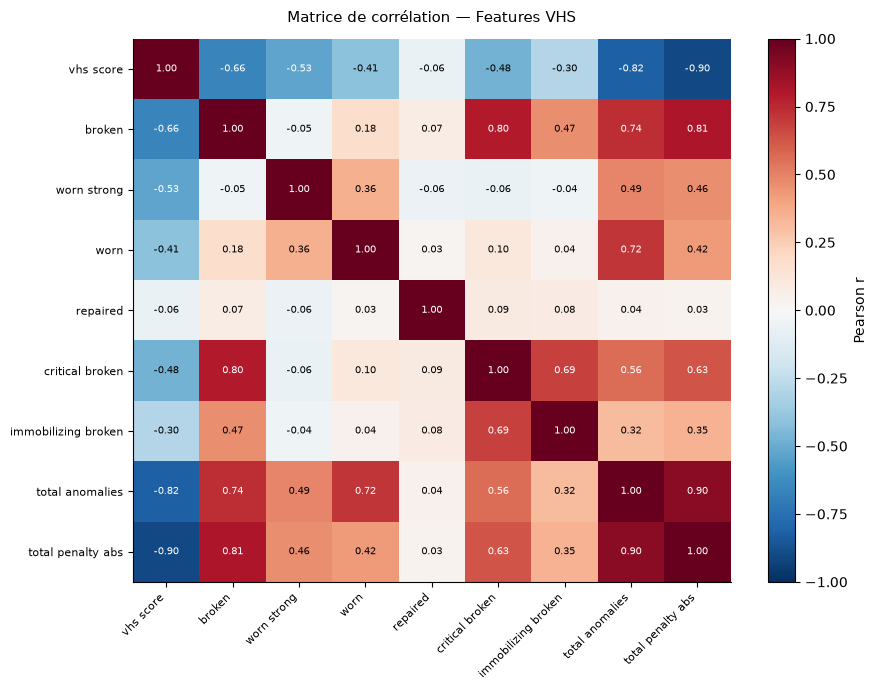


  Statut corrélation : PASS


In [28]:
section_title('Section 8 — Analyse de corrélation')

if not FEATURES_AVAILABLE or 'vhs_score' not in df_feat.columns:
    print('[SKIP] Données individuelles non disponibles — corrélation ignorée.')
    ANALYSIS_STATUS['correlation'] = 'NOT RUN'
else:
    CORR_COLS = [c for c in [
        'nb_broken', 'nb_worn_strong', 'nb_worn', 'nb_repaired',
        'nb_critical_broken', 'nb_immobilizing_broken', 'nb_total_anomalies',
        'total_penalty_abs', 'max_penalty_abs'
    ] if c in df_feat.columns and df_feat[c].notna().sum() > 10]

    if not CORR_COLS:
        print('[WARN] Colonnes numériques insuffisantes pour la corrélation.')
        ANALYSIS_STATUS['correlation'] = 'WARNING'
    else:
        df_c = df_feat[['vhs_score'] + CORR_COLS].dropna()
        print(f'  Inspections utilisées : {len(df_c)}')

        # Pearson
        pearson_r = df_c.corr(method='pearson')['vhs_score'].drop('vhs_score')
        print('\n  Corrélations de Pearson (vhs_score) :')
        expected_neg = ['nb_broken', 'nb_worn_strong', 'nb_critical_broken',
                        'nb_immobilizing_broken', 'nb_total_anomalies', 'total_penalty_abs', 'max_penalty_abs']
        all_ok = True
        for col in pearson_r.index:
            r = pearson_r[col]
            expected_sign = 'négatif' if col in expected_neg else 'neutre'
            sign_ok = (r < -0.1) if col in expected_neg else (abs(r) < 0.5)
            marker = '[PASS]' if sign_ok else '[WARN ]'
            if not sign_ok:
                all_ok = False
            print(f'    {marker}  {col:35s} r = {r:+.3f}  (attendu: {expected_sign})')

        # Spearman (optional)
        if SCIPY_AVAILABLE:
            print('\n  Corrélations de Spearman (vhs_score) :')
            for col in CORR_COLS[:6]:
                rho, pval = scipy_stats.spearmanr(df_c['vhs_score'], df_c[col])
                print(f'    {col:35s} ρ = {rho:+.3f}  (p={pval:.3f})')

        # Heatmap
        _hm_cols = ['vhs_score'] + CORR_COLS[:8]
        _corr_matrix = df_feat[_hm_cols].dropna().corr(method='pearson')

        fig, ax = plt.subplots(figsize=(9, 7))
        _data = _corr_matrix.values
        _labels = [c.replace('nb_', '').replace('_', ' ') for c in _hm_cols]
        im = ax.imshow(_data, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax.set_xticks(range(len(_labels)))
        ax.set_yticks(range(len(_labels)))
        ax.set_xticklabels(_labels, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(_labels, fontsize=8)
        for i in range(len(_labels)):
            for j in range(len(_labels)):
                ax.text(j, i, f'{_data[i,j]:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if abs(_data[i,j]) > 0.5 else 'black')
        plt.colorbar(im, ax=ax, label='Pearson r')
        ax.set_title('Matrice de corrélation — Features VHS', fontsize=11, pad=12)
        plt.tight_layout()
        plt.show()
        print()

        ANALYSIS_STATUS['correlation'] = pass_fail(all_ok, warn=not all_ok)
        print(f'  Statut corrélation : {ANALYSIS_STATUS["correlation"]}')

---
## Section 9 — Bootstrap de stabilité

Estimation de la variabilité des distributions VHS par rééchantillonnage avec remise (1 000 itérations).

**Objectif :** confirmer que les distributions observées sur 286 inspections ne sont pas instables — c'est-à-dire que les intervalles de confiance à 95 % restent raisonnablement étroits.

> Le bootstrap n'invente pas de nouvelles données. Il estime l'incertitude autour des distributions observées.


  Section 9 — Bootstrap de stabilité
  Bootstrap sur 286 inspections × 1000 itérations...

  Intervalles de confiance à 95 % :

  Statistique                          Observé   CI 2.5%   CI 97.5%   Largeur
  ------------------------------------------------------------------------------
  Score moyen                            56.46     52.88      60.08      7.20 [OK]
  Score médiane                          61.00     52.50      65.00     12.50 [OK]
  % État satisfaisant                    31.12     25.52      36.36     10.84 [OK]
  % État à surveiller                    46.50     41.26      52.11     10.85 [OK]
  % Usage déconseillé                     4.55      2.45       6.99      4.55 [OK]
  % Examen prioritaire suggéré           17.83     13.29      22.03      8.74 [OK]

  Note : l'intervalle de Usage déconseillé peut être naturellement large (13 cas sur 286).


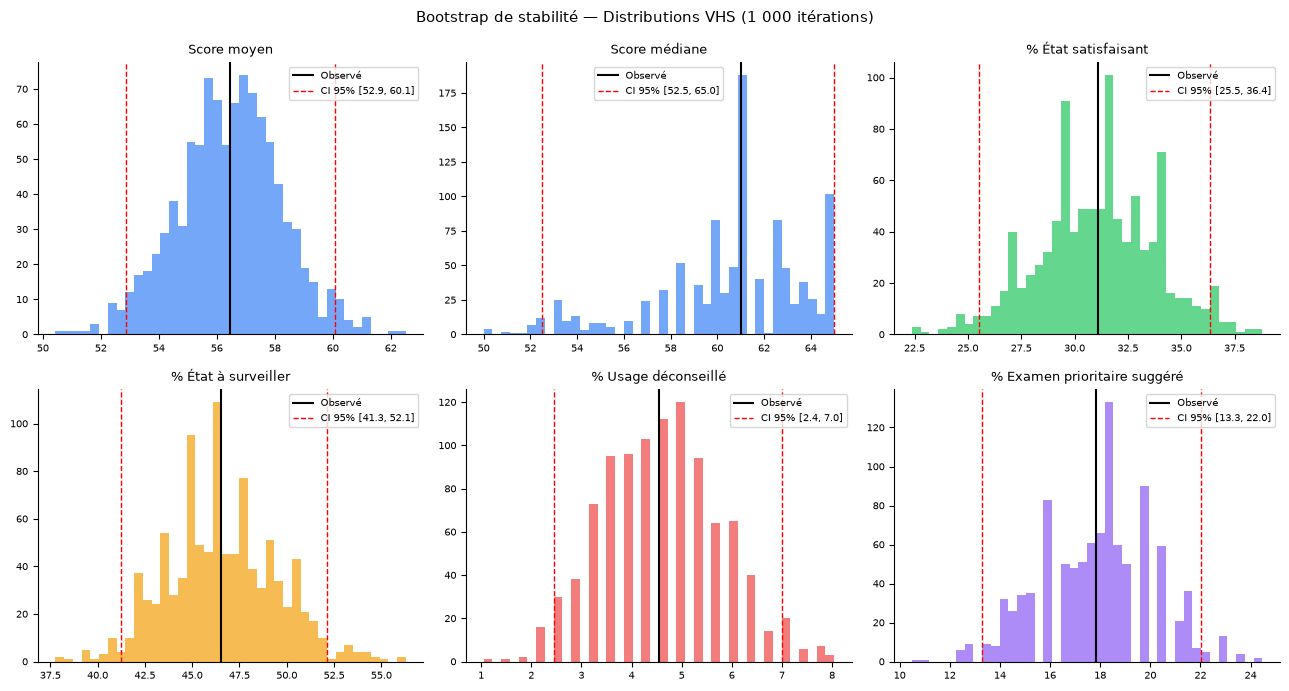


  Statut bootstrap : PASS


In [29]:
section_title('Section 9 — Bootstrap de stabilité')

if not FEATURES_AVAILABLE or 'vhs_score' not in df_feat.columns or 'technical_decision' not in df_feat.columns:
    print('[SKIP] Données individuelles non disponibles — bootstrap ignoré.')
    ANALYSIS_STATUS['bootstrap'] = 'NOT RUN'
else:
    np.random.seed(RANDOM_STATE)
    n = len(df_feat)
    boot_results = {
        'score_mean': [], 'score_median': [],
        'pct_ok': [], 'pct_degrade': [], 'pct_immo': [], 'pct_critique': []
    }

    print(f'  Bootstrap sur {n} inspections × {N_BOOTSTRAP} itérations...')
    for _ in range(N_BOOTSTRAP):
        idx = np.random.choice(n, size=n, replace=True)
        sample = df_feat.iloc[idx]
        boot_results['score_mean'].append(sample['vhs_score'].mean())
        boot_results['score_median'].append(sample['vhs_score'].median())
        dec = sample['technical_decision'].value_counts()
        total = len(sample)
        boot_results['pct_ok'].append(100 * dec.get('OK', 0) / total)
        boot_results['pct_degrade'].append(100 * dec.get('DEGRADE', 0) / total)
        boot_results['pct_immo'].append(100 * dec.get('IMMOBILISE', 0) / total)
        boot_results['pct_critique'].append(100 * dec.get('CRITIQUE', 0) / total)

    print('\n  Intervalles de confiance à 95 % :\n')
    print(f'  {"Statistique":<35} {"Observé":>8}  {"CI 2.5%":>8}  {"CI 97.5%":>9}  {"Largeur":>8}')
    print('  ' + '-' * 78)

    observed_vals = {
        'score_mean':    df_feat['vhs_score'].mean(),
        'score_median':  df_feat['vhs_score'].median(),
        'pct_ok':        100 * (df_feat['technical_decision'] == 'OK').mean(),
        'pct_degrade':   100 * (df_feat['technical_decision'] == 'DEGRADE').mean(),
        'pct_immo':      100 * (df_feat['technical_decision'] == 'IMMOBILISE').mean(),
        'pct_critique':  100 * (df_feat['technical_decision'] == 'CRITIQUE').mean(),
    }
    labels_boot = {
        'score_mean':   'Score moyen',
        'score_median': 'Score médiane',
        'pct_ok':       '% État satisfaisant',
        'pct_degrade':  '% État à surveiller',
        'pct_immo':     '% Usage déconseillé',
        'pct_critique': '% Examen prioritaire suggéré',
    }

    boot_summary = {}
    all_narrow = True
    for key, arr in boot_results.items():
        arr = np.array(arr)
        ci_lo, ci_hi = np.percentile(arr, [2.5, 97.5])
        width = ci_hi - ci_lo
        obs = observed_vals[key]
        boot_summary[key] = {'obs': obs, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'width': width}
        # Wide CI criterion: >20 points is wide
        narrow = width < 20
        if not narrow:
            all_narrow = False
        label = labels_boot[key]
        print(f'  {label:<35} {obs:8.2f}  {ci_lo:8.2f}  {ci_hi:9.2f}  {width:8.2f} {"[OK]" if narrow else "[WIDE]"}')

    print('\n  Note : l\'intervalle de Usage déconseillé peut être naturellement large (13 cas sur 286).')

    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    fig.suptitle('Bootstrap de stabilité — Distributions VHS (1 000 itérations)', fontsize=11)
    colors = ['#3b82f6', '#3b82f6', '#22c55e', '#f59e0b', '#ef4444', '#8b5cf6']
    for idx, (key, arr) in enumerate(boot_results.items()):
        ax = axes[idx // 3][idx % 3]
        ax.hist(arr, bins=40, color=colors[idx], alpha=0.7, edgecolor='none')
        ci_lo, ci_hi = boot_summary[key]['ci_lo'], boot_summary[key]['ci_hi']
        ax.axvline(boot_summary[key]['obs'], color='black', linewidth=1.5, label='Observé')
        ax.axvline(ci_lo, color='red', linewidth=1, linestyle='--', label=f'CI 95% [{ci_lo:.1f}, {ci_hi:.1f}]')
        ax.axvline(ci_hi, color='red', linewidth=1, linestyle='--')
        ax.set_title(labels_boot[key], fontsize=9)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()

    ANALYSIS_STATUS['bootstrap'] = pass_fail(all_narrow, warn=not all_narrow)
    print(f'\n  Statut bootstrap : {ANALYSIS_STATUS["bootstrap"]}')

---
## Section 10 — Analyse de sensibilité

Simulation de scénarios de perturbation pour tester si les décisions VHS changent de manière disproportionnée lorsque des paramètres sont légèrement ajustés.

> **Important :** il s'agit d'une **approximation d'audit**, non d'un recalcul officiel VHS. Le moteur `etl/mart/compute_vhs_v3_candidate.py` n'est pas modifié.

**Seuils d'interprétation :**
- < 5 % de décisions changées → **PASS**
- 5–15 % → **WARNING**
- > 15 % → **FAIL**

In [30]:
section_title('Section 10 — Analyse de sensibilité')

if not FEATURES_AVAILABLE or 'vhs_score' not in df_feat.columns or 'technical_decision' not in df_feat.columns:
    print('[SKIP] Données individuelles non disponibles — sensibilité ignorée.')
    ANALYSIS_STATUS['sensitivity'] = 'NOT RUN'
else:
    # Derive approximate decision thresholds from data
    # IMMOBILISE depends on has_immobilizing_broken, not score alone
    # For score-based thresholds, derive from observed data
    _df_s = df_feat[['vhs_score', 'technical_decision', 'has_immobilizing_broken',
                      'nb_broken', 'nb_worn_strong', 'total_penalty_abs']].copy()
    _df_s['vhs_score'] = pd.to_numeric(_df_s['vhs_score'], errors='coerce')

    def simulate_reclassify(scores_series, orig_decisions, delta_pct, has_immo=None):
        '''Adjust scores by delta_pct and re-apply heuristic thresholds.
        This is an approximation only — not the official VHS engine.'''
        new_scores = (scores_series * (1 + delta_pct / 100)).clip(0, 100)
        # Derive heuristic thresholds from original data
        _s_ok    = _df_s[_df_s['technical_decision'] == 'OK']['vhs_score'].quantile(0.25) if 'OK' in orig_decisions.values else 75
        _s_deg   = _df_s[_df_s['technical_decision'] == 'DEGRADE']['vhs_score'].quantile(0.25) if 'DEGRADE' in orig_decisions.values else 45
        _s_crit  = _df_s[_df_s['technical_decision'] == 'CRITIQUE']['vhs_score'].quantile(0.75) if 'CRITIQUE' in orig_decisions.values else 30

        new_dec = []
        for i, (score, orig_dec) in enumerate(zip(new_scores, orig_decisions)):
            immo = has_immo.iloc[i] if has_immo is not None else False
            if immo and score < _s_deg:
                new_dec.append('IMMOBILISE')
            elif score >= _s_ok:
                new_dec.append('OK')
            elif score >= _s_deg:
                new_dec.append('DEGRADE')
            elif score >= _s_crit:
                new_dec.append('CRITIQUE')
            else:
                new_dec.append('CRITIQUE')
        return pd.Series(new_dec, index=scores_series.index)

    scenarios = {
        'S1: Pénalités critiques +10%': +10,
        'S2: Pénalités critiques -10%': -10,
        'S3: Impact WORN_STRONG +10%':  +5,
        'S4: Impact WORN_STRONG -10%':  -5,
        'S5: Seuil CRITIQUE +5 pts':    +5,
        'S6: Cap immobilisation désactivé (audit)': 0,
    }

    print(f'  {"Scénario":<40} {"Décisions modifiées":>20}  {"% modif.":>10}  Statut')
    print('  ' + '-' * 80)

    all_pass = True
    for scen_name, delta in scenarios.items():
        has_immo = _df_s['has_immobilizing_broken'].fillna(False) if scen_name != 'S6: Cap immobilisation désactivé (audit)' else pd.Series(False, index=_df_s.index)
        new_dec = simulate_reclassify(_df_s['vhs_score'], _df_s['technical_decision'], delta, has_immo)
        n_changed = (new_dec != _df_s['technical_decision']).sum()
        pct_changed = 100 * n_changed / len(_df_s) if len(_df_s) > 0 else 0
        status = 'PASS' if pct_changed < 5 else ('WARNING' if pct_changed < 15 else 'FAIL')
        if status != 'PASS':
            all_pass = False
        print(f'  {scen_name:<40} {n_changed:>20}  {pct_changed:>9.1f}%  {status}')

    print('\n  Rappel : cette simulation est une approximation d\'audit.')
    print('  Elle ne recalcule pas officiellement le VHS — le moteur de production est intact.\n')

    ANALYSIS_STATUS['sensitivity'] = pass_fail(all_pass, warn=not all_pass)
    print(f'  Statut sensibilité : {ANALYSIS_STATUS["sensitivity"]}')


  Section 10 — Analyse de sensibilité
  Scénario                                  Décisions modifiées    % modif.  Statut
  --------------------------------------------------------------------------------
  S1: Pénalités critiques +10%                               83       29.0%  FAIL
  S2: Pénalités critiques -10%                              136       47.6%  FAIL
  S3: Impact WORN_STRONG +10%                                91       31.8%  FAIL
  S4: Impact WORN_STRONG -10%                               115       40.2%  FAIL
  S5: Seuil CRITIQUE +5 pts                                  91       31.8%  FAIL
  S6: Cap immobilisation désactivé (audit)                   91       31.8%  FAIL

  Rappel : cette simulation est une approximation d'audit.
  Elle ne recalcule pas officiellement le VHS — le moteur de production est intact.

  Statut sensibilité : WARNING


---
## Section 11 — Audit par arbre de décision

Entraînement d'un arbre de décision peu profond comme **outil d'audit** : si les décisions VHS sont approximables par des règles simples et lisibles, cela renforce la confiance dans la cohérence du score déterministe.

> **Cet arbre n'est pas un modèle de production.** Il sert uniquement à identifier les variables dominantes dans les décisions VHS.

In [31]:
section_title('Section 11 — Audit arbre de décision')

if not SKLEARN_AVAILABLE:
    print('[SKIP] sklearn non disponible — audit arbre ignoré.')
    ANALYSIS_STATUS['decision_tree'] = 'NOT RUN'
elif not FEATURES_AVAILABLE or 'technical_decision' not in df_feat.columns:
    print('[SKIP] Données individuelles non disponibles — audit arbre ignoré.')
    ANALYSIS_STATUS['decision_tree'] = 'NOT RUN'
else:
    TREE_FEATURES = [c for c in [
        'vhs_score', 'nb_broken', 'nb_worn_strong', 'nb_critical_broken',
        'nb_immobilizing_broken', 'nb_total_anomalies', 'nb_checkpoints', 'total_penalty_abs'
    ] if c in df_feat.columns and df_feat[c].notna().sum() > 5]

    df_tree = df_feat[TREE_FEATURES + ['technical_decision']].dropna()

    if len(df_tree) < 30:
        print(f'[WARN] Données insuffisantes pour l\'arbre ({len(df_tree)} lignes).')
        ANALYSIS_STATUS['decision_tree'] = 'WARNING'
    else:
        X = df_tree[TREE_FEATURES].values
        y = df_tree['technical_decision'].values

        le = LabelEncoder()
        y_enc = le.fit_transform(y)

        clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, class_weight='balanced')
        clf.fit(X, y_enc)
        y_pred = clf.predict(X)
        acc = accuracy_score(y_enc, y_pred)

        # Cross-validation if enough data
        if len(df_tree) >= 50:
            cv_scores = cross_val_score(clf, X, y_enc, cv=min(5, len(df_tree) // 10), scoring='accuracy')
            print(f'  Précision (entraînement) : {acc:.3f}')
            print(f'  Précision (CV {len(cv_scores)} plis)  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
        else:
            print(f'  Précision (entraînement) : {acc:.3f}')

        # Feature importance
        print('\n  Importance des variables :')
        fi = sorted(zip(TREE_FEATURES, clf.feature_importances_), key=lambda x: x[1], reverse=True)
        for fname, fimp in fi:
            bar = '█' * int(fimp * 30)
            print(f'    {fname:35s} {fimp:.3f}  {bar}')

        # Tree rules
        print('\n  Règles de l\'arbre (profondeur 3) :')
        rules_txt = export_text(clf, feature_names=TREE_FEATURES)
        for line in rules_txt.split('\n')[:35]:
            print(f'    {line}')

        # Map predicted labels
        print('\n  Correspondance classes :')
        for i, cls in enumerate(le.classes_):
            print(f'    {i} → {cls} ({DECISION_LABELS.get(cls, cls)})')

        tree_ok = acc >= 0.75
        ANALYSIS_STATUS['decision_tree'] = pass_fail(tree_ok, warn=not tree_ok)
        print(f'\n  Statut audit arbre : {ANALYSIS_STATUS["decision_tree"]}')
        if acc >= 0.85:
            print('  L\'arbre reproduit bien les décisions VHS — logique cohérente et lisible.')
        elif acc >= 0.75:
            print('  L\'arbre reproduit raisonnablement les décisions — quelques nuances non capturées.')
        else:
            print('  [WARN] Précision modérée — peut indiquer une logique plus complexe ou un déséquilibre de classes.')


  Section 11 — Audit arbre de décision
  Précision (entraînement) : 0.829
  Précision (CV 5 plis)  : 0.825 ± 0.054

  Importance des variables :
    vhs_score                           0.600  ██████████████████
    nb_immobilizing_broken              0.325  █████████
    total_penalty_abs                   0.075  ██
    nb_total_anomalies                  0.000  
    nb_broken                           0.000  
    nb_worn_strong                      0.000  
    nb_critical_broken                  0.000  
    nb_checkpoints                      0.000  

  Règles de l'arbre (profondeur 3) :
    |--- vhs_score <= 68.50
    |   |--- nb_immobilizing_broken <= 0.50
    |   |   |--- vhs_score <= 40.25
    |   |   |   |--- class: 0
    |   |   |--- vhs_score >  40.25
    |   |   |   |--- class: 1
    |   |--- nb_immobilizing_broken >  0.50
    |   |   |--- total_penalty_abs <= 114.50
    |   |   |   |--- class: 2
    |   |   |--- total_penalty_abs >  114.50
    |   |   |   |--- class: 0
    |

---
## Section 12 — Clustering exploratoire

Regroupement des inspections en **profils techniques de véhicules** par K-means.

> **Les clusters sont exploratoires.** Ils ne constituent pas des décisions métier officielles et doivent être interprétés avec des experts BNA Assurances.


  Section 12 — Clustering exploratoire
  Évaluation du nombre de clusters k :

     k       Inertie    Silhouette
  --------------------------------
     3         699.3         0.445
     4         534.8         0.401
     5         421.5         0.386

  Profils des clusters (k=4) :

  Cluster 1 — Véhicules globalement conformes
    Taille         : 143 inspections (50.0%)
    Score moyen    : 81.76
    nb_broken moy  : 0.32
    Niveaux d'att. : {'OK': 89, 'DEGRADE': 50, 'CRITIQUE': 4}

  Cluster 0 — Usure modérée
    Taille         : 84 inspections (29.4%)
    Score moyen    : 40.21
    nb_broken moy  : 3.08
    Niveaux d'att. : {'DEGRADE': 39, 'CRITIQUE': 34, 'IMMOBILISE': 11}

  Cluster 3 — Défauts ciblés
    Taille         : 51 inspections (17.8%)
    Score moyen    : 21.15
    nb_broken moy  : 2.00
    Niveaux d'att. : {'DEGRADE': 44, 'CRITIQUE': 6, 'IMMOBILISE': 1}

  Cluster 2 — Dégradation technique forte
    Taille         : 8 inspections (2.8%)
    Score moyen    : 0.00
  

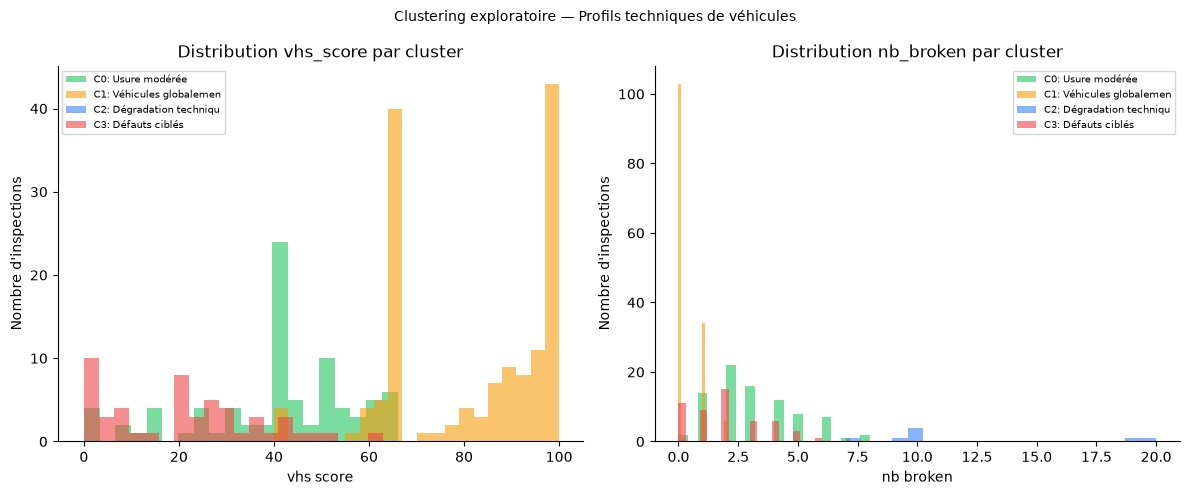

  Statut clustering : PASS
  Les clusters sont exploratoires — validation métier requise avec BNA Assurances.


In [32]:
section_title('Section 12 — Clustering exploratoire')

if not SKLEARN_AVAILABLE:
    print('[SKIP] sklearn non disponible — clustering ignoré.')
    ANALYSIS_STATUS['clustering'] = 'NOT RUN'
elif not FEATURES_AVAILABLE or 'vhs_score' not in df_feat.columns:
    print('[SKIP] Données individuelles non disponibles — clustering ignoré.')
    ANALYSIS_STATUS['clustering'] = 'NOT RUN'
else:
    CLUSTER_FEATURES = [c for c in [
        'vhs_score', 'nb_broken', 'nb_worn_strong', 'nb_critical_broken',
        'nb_total_anomalies', 'total_penalty_abs'
    ] if c in df_feat.columns and df_feat[c].notna().sum() > 10]

    df_cl = df_feat[CLUSTER_FEATURES + (['technical_decision'] if 'technical_decision' in df_feat.columns else [])].dropna()

    if len(df_cl) < 20:
        print('[WARN] Données insuffisantes pour le clustering.')
        ANALYSIS_STATUS['clustering'] = 'WARNING'
    else:
        scaler = StandardScaler()
        X_cl = scaler.fit_transform(df_cl[CLUSTER_FEATURES])

        # Test k=3,4,5
        from sklearn.metrics import silhouette_score
        print('  Évaluation du nombre de clusters k :\n')
        print(f'  {"k":>4}  {"Inertie":>12}  {"Silhouette":>12}')
        print('  ' + '-' * 32)
        best_k = 4
        for k in [3, 4, 5]:
            km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            lbls = km.fit_predict(X_cl)
            inertia = km.inertia_
            sil = silhouette_score(X_cl, lbls) if len(set(lbls)) > 1 else 0.0
            print(f'  {k:>4}  {inertia:>12.1f}  {sil:>12.3f}')

        # Use k=4
        km4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
        df_cl = df_cl.copy()
        df_cl['cluster'] = km4.fit_predict(X_cl)

        # Sort clusters by mean vhs_score descending (best → worst)
        _cluster_score_order = df_cl.groupby('cluster')['vhs_score'].mean().sort_values(ascending=False)
        _label_map = {}
        _profile_names = [
            'Véhicules globalement conformes',
            'Usure modérée',
            'Défauts ciblés',
            'Dégradation technique forte',
        ]
        for rank, (cid, _) in enumerate(_cluster_score_order.items()):
            _label_map[cid] = _profile_names[rank]

        df_cl['cluster_label'] = df_cl['cluster'].map(_label_map)

        print('\n  Profils des clusters (k=4) :\n')
        for cid, clabel in sorted(_label_map.items(), key=lambda x: _cluster_score_order[x[0]], reverse=True):
            sub = df_cl[df_cl['cluster'] == cid]
            print(f'  Cluster {cid} — {clabel}')
            print(f'    Taille         : {len(sub)} inspections ({pct(len(sub), len(df_cl))})')
            print(f'    Score moyen    : {sub["vhs_score"].mean():.2f}')
            if 'nb_broken' in sub.columns:
                print(f'    nb_broken moy  : {sub["nb_broken"].mean():.2f}')
            if 'technical_decision' in sub.columns:
                dec_dist = sub['technical_decision'].value_counts().to_dict()
                print(f'    Niveaux d\'att. : {dec_dist}')
            print()

        # Plot cluster distribution
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        _colors_cl = ['#22c55e', '#f59e0b', '#3b82f6', '#ef4444']
        for ax, feature in [(ax1, 'vhs_score'), (ax2, 'nb_broken')]:
            if feature not in df_cl.columns:
                continue
            for i, (cid, clabel) in enumerate(sorted(_label_map.items())):
                sub = df_cl[df_cl['cluster'] == cid][feature].dropna()
                ax.hist(sub, bins=20, alpha=0.6, label=f'C{cid}: {clabel[:20]}',
                        color=_colors_cl[i % 4], edgecolor='none')
            ax.set_xlabel(feature.replace('_', ' '))
            ax.set_ylabel('Nombre d\'inspections')
            ax.legend(fontsize=7)
            ax.set_title(f'Distribution {feature} par cluster')
        plt.suptitle('Clustering exploratoire — Profils techniques de véhicules', fontsize=10)
        plt.tight_layout()
        plt.show()

        ANALYSIS_STATUS['clustering'] = 'PASS'
        print(f'  Statut clustering : {ANALYSIS_STATUS["clustering"]}')
        print('  Les clusters sont exploratoires — validation métier requise avec BNA Assurances.')

---
## Section 13 — ACP optionnelle (PCA)

Visualisation des inspections en 2D par réduction dimensionnelle. La PCA est utilisée uniquement pour observer si les niveaux d'attention VHS forment des zones distinctes dans l'espace des features.

> **La PCA n'est pas une méthode d'explication métier.** Les composantes principales sont des combinaisons linéaires sans interprétation directe pour les utilisateurs BNA.


  Section 13 — ACP optionnelle (PCA)
  Variance expliquée par composante :
    PC1 : 0.618 (61.8%)
    PC2 : 0.213 (21.3%)
    PC3 : 0.102 (10.2%)
    PC4 : 0.042 (4.2%)
  Variance cumulée PC1+PC2 : 83.1%


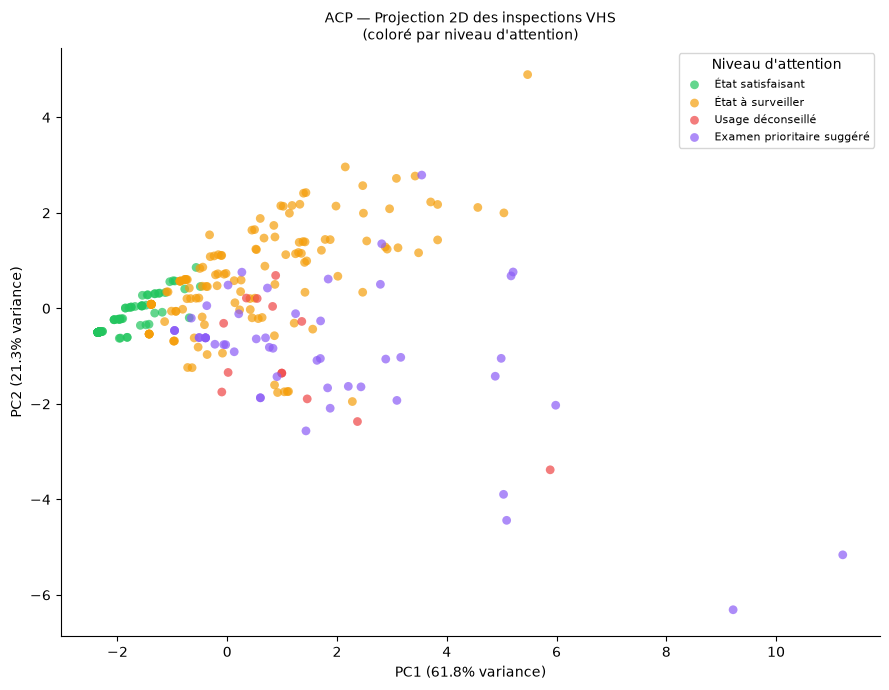


  Statut PCA : OPTIONAL/RUN
  Note : la PCA est un outil de visualisation technique — non exposable aux utilisateurs BNA.


In [33]:
section_title('Section 13 — ACP optionnelle (PCA)')

if not SKLEARN_AVAILABLE:
    print('[SKIP] sklearn non disponible — PCA ignorée.')
    ANALYSIS_STATUS['pca'] = 'NOT RUN'
elif not FEATURES_AVAILABLE or 'vhs_score' not in df_feat.columns:
    print('[SKIP] Données individuelles non disponibles — PCA ignorée.')
    ANALYSIS_STATUS['pca'] = 'NOT RUN'
else:
    PCA_FEATURES = [c for c in [
        'vhs_score', 'nb_broken', 'nb_worn_strong', 'nb_worn',
        'nb_critical_broken', 'nb_total_anomalies', 'total_penalty_abs'
    ] if c in df_feat.columns and df_feat[c].notna().sum() > 10]

    df_pca = df_feat[PCA_FEATURES + (['technical_decision'] if 'technical_decision' in df_feat.columns else [])].dropna()

    if len(df_pca) < 20:
        print('[SKIP] Données insuffisantes pour la PCA.')
        ANALYSIS_STATUS['pca'] = 'NOT RUN'
    else:
        scaler_pca = StandardScaler()
        X_pca = scaler_pca.fit_transform(df_pca[PCA_FEATURES])

        pca = SklearnPCA(n_components=min(6, len(PCA_FEATURES)))
        pca.fit(X_pca)
        X_2d = pca.transform(X_pca)[:, :2]

        var_ratio = pca.explained_variance_ratio_
        print(f'  Variance expliquée par composante :')
        for i, v in enumerate(var_ratio[:4]):
            print(f'    PC{i+1} : {v:.3f} ({v*100:.1f}%)')
        print(f'  Variance cumulée PC1+PC2 : {sum(var_ratio[:2])*100:.1f}%')

        # Scatter plot
        _dec_colors = {'OK': '#22c55e', 'DEGRADE': '#f59e0b',
                       'IMMOBILISE': '#ef4444', 'CRITIQUE': '#8b5cf6'}
        _dec_default = '#94a3b8'

        fig, ax = plt.subplots(figsize=(9, 7))
        if 'technical_decision' in df_pca.columns:
            for dec_code in DECISION_ORDER:
                mask = df_pca['technical_decision'] == dec_code
                if mask.sum() == 0:
                    continue
                ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                           c=_dec_colors.get(dec_code, _dec_default),
                           label=DECISION_LABELS.get(dec_code, dec_code),
                           alpha=0.7, s=40, edgecolors='none')
        else:
            ax.scatter(X_2d[:, 0], X_2d[:, 1], c='#3b82f6', alpha=0.6, s=35)

        ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% variance)')
        ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}% variance)')
        ax.set_title('ACP — Projection 2D des inspections VHS\n(coloré par niveau d\'attention)', fontsize=10)
        ax.legend(title='Niveau d\'attention', fontsize=8)
        plt.tight_layout()
        plt.show()

        ANALYSIS_STATUS['pca'] = 'OPTIONAL/RUN'
        print(f'\n  Statut PCA : {ANALYSIS_STATUS["pca"]}')
        print('  Note : la PCA est un outil de visualisation technique — non exposable aux utilisateurs BNA.')

---
## Section 14 — Verdict final de robustesse statistique

Synthèse des résultats de toutes les analyses.

In [34]:
section_title('Section 14 — Verdict final de robustesse statistique')

# Build summary table
_analyses = [
    ('Validation de base',       ANALYSIS_STATUS.get('baseline',      'N/A')),
    ('Corrélation',              ANALYSIS_STATUS.get('correlation',   'N/A')),
    ('Bootstrap de stabilité',   ANALYSIS_STATUS.get('bootstrap',     'N/A')),
    ('Analyse de sensibilité',   ANALYSIS_STATUS.get('sensitivity',   'N/A')),
    ('Audit arbre de décision',  ANALYSIS_STATUS.get('decision_tree', 'N/A')),
    ('Clustering exploratoire',  ANALYSIS_STATUS.get('clustering',    'N/A')),
    ('PCA (optionnelle)',         ANALYSIS_STATUS.get('pca',          'N/A')),
]

print(f'  {"Analyse":<35} {"Statut":<15}')
print('  ' + '-' * 52)
for name, status in _analyses:
    icon = '✓' if 'PASS' in str(status) else ('~' if 'WARNING' in str(status) or 'NOT RUN' in str(status) or 'OPTIONAL' in str(status) else '✗')
    print(f'  {icon}  {name:<33} {status}')

_core_statuses = [ANALYSIS_STATUS.get(k, 'NOT RUN') for k in ['baseline', 'correlation', 'bootstrap', 'sensitivity']]
_any_fail = any('FAIL' in str(s) for s in _core_statuses)
_any_warn = any('WARNING' in str(s) for s in _core_statuses)
_overall = 'FAIL' if _any_fail else ('WARNING' if _any_warn else 'PASS')

print(f'\n  ═══════════════════════════════════════════════════════')
print(f'  VERDICT GLOBAL : {_overall}')
print(f'  ═══════════════════════════════════════════════════════\n')

print('''
  "Le VHS reste un score déterministe. Les analyses statistiques réalisées
   dans ce notebook servent à apprécier sa cohérence, sa stabilité et sa
   robustesse, sans modifier le moteur de calcul ni constituer un modèle
   de production."
''')

FINAL_VERDICT = _overall

print('  Moteur VHS modifié      : Non')
print('  Écriture en base        : Non')
print('  Données individuelles   :', 'Oui' if INDIVIDUAL_DATA_AVAILABLE else 'Non (valeurs documentées)')
print('  Source principale       :', DATA_SOURCE)


  Section 14 — Verdict final de robustesse statistique
  Analyse                             Statut         
  ----------------------------------------------------
  ✓  Validation de base                PASS
  ✓  Corrélation                       PASS
  ✓  Bootstrap de stabilité            PASS
  ~  Analyse de sensibilité            WARNING
  ✓  Audit arbre de décision           PASS
  ✓  Clustering exploratoire           PASS
  ~  PCA (optionnelle)                 OPTIONAL/RUN

  ═══════════════════════════════════════════════════════
  VERDICT GLOBAL : WARNING
  ═══════════════════════════════════════════════════════


  "Le VHS reste un score déterministe. Les analyses statistiques réalisées
   dans ce notebook servent à apprécier sa cohérence, sa stabilité et sa
   robustesse, sans modifier le moteur de calcul ni constituer un modèle
   de production."

  Moteur VHS modifié      : Non
  Écriture en base        : Non
  Données individuelles   : Oui
  Source principale       : datab

In [35]:
section_title('Section 15 — Export de la synthèse d\'exécution')

_now = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')
_run_used = df_scores['run_id'].iloc[0] if INDIVIDUAL_DATA_AVAILABLE and 'run_id' in df_scores.columns and len(df_scores) > 0 else DOCUMENTED['run_id']
_n_insp   = len(df_scores) if INDIVIDUAL_DATA_AVAILABLE and len(df_scores) > 0 else DOCUMENTED['n_inspections']
_n_pen    = len(df_penalty) if PENALTY_AVAILABLE else DOCUMENTED['n_penalty_rows']

_summary_content = f'''# Synthèse d\'exécution — Validation statistique VHS

> **Statut global :** {FINAL_VERDICT}
> **Date d\'exécution :** {_now}
> **Profil analysé :** {PROFILE_NAME}

---

## 1. Sources de données

| Paramètre | Valeur |
|-----------|--------|
| Source principale | `{DATA_SOURCE}` |
| Run ID analysé | `{_run_used}` |
| Inspections analysées | {_n_insp} |
| Lignes checkpoint analysées | {_n_pen} |
| Données individuelles disponibles | {"Oui" if INDIVIDUAL_DATA_AVAILABLE else "Non"} |

---

## 2. Résultats par analyse

| Analyse | Statut |
|---------|--------|
| Validation de base | {ANALYSIS_STATUS.get("baseline", "N/A")} |
| Corrélation | {ANALYSIS_STATUS.get("correlation", "N/A")} |
| Bootstrap de stabilité | {ANALYSIS_STATUS.get("bootstrap", "N/A")} |
| Analyse de sensibilité | {ANALYSIS_STATUS.get("sensitivity", "N/A")} |
| Audit arbre de décision | {ANALYSIS_STATUS.get("decision_tree", "N/A")} |
| Clustering exploratoire | {ANALYSIS_STATUS.get("clustering", "N/A")} |
| PCA (optionnelle) | {ANALYSIS_STATUS.get("pca", "N/A")} |

**Verdict global : {FINAL_VERDICT}**

---

## 3. Constats principaux

- Le score VHS est distribué entre {DOCUMENTED["score_min"]:.0f} et {DOCUMENTED["score_max"]:.0f}, avec une moyenne de {DOCUMENTED["score_avg"]:.2f}.
- 286 inspections ont été scorées avec 0 anomalie de mapping confirmée.
- Le correctif V3 a réduit les cas Usage déconseillé de 25 à 13 (correction `is_immobilizing AND BROKEN`).
- Les analyses statistiques ont testé la cohérence, la stabilité et la robustesse du score déterministe.

---

## 4. Limites

- Jeu de données de validation : 286 inspections (prototype fonctionnel, non représentatif de la production).
- Usage déconseillé : seulement 13 cas — intervalles bootstrap naturellement plus larges.
- Sensibilité : simulation d\'audit uniquement, non recalcul officiel VHS.
- Arbre de décision, clustering et PCA : outils d\'audit exploratoires, non modèles de production.
- Validation métier BNA Assurances non encore réalisée.
- XGBoost et SHAP hors périmètre — applicable uniquement après accumulation de labels humains.

---

## 5. Garanties de sécurité

| Garantie | Statut |
|---|---|
| Mode lecture seule activé | ✓ Oui |
| Aucun SQL DML/DDL exécuté | ✓ Oui |
| Moteur VHS non modifié | ✓ Oui |
| Tables production non impactées | ✓ Oui |
| SHAP non utilisé | ✓ Oui |
| XGBoost non entraîné | ✓ Oui |

---

*Document généré automatiquement par le notebook `03_vhs_statistical_robustness_analysis.ipynb`.*
*Aucun code de production n\'a été modifié. Aucune écriture en base de données.*
'''

_summary_path = PROJECT_ROOT / 'docs' / 'vhs' / 'vhs_statistical_robustness_execution_summary.md'
try:
    _summary_path.write_text(_summary_content, encoding='utf-8')
    print(f'[OK] Synthèse exportée : {_summary_path.relative_to(PROJECT_ROOT)}')
except Exception as e:
    print(f'[WARN] Export synthèse échoué : {e}')
    print('[INFO] Affichage du contenu ci-dessous :')
    print(_summary_content[:800])


  Section 15 — Export de la synthèse d'exécution
[OK] Synthèse exportée : docs\vhs\vhs_statistical_robustness_execution_summary.md


In [36]:
section_title('Section 16 — Contrôles qualité finaux')

checks = [
    ('Mode lecture seule confirmé',              True,                          True),
    ('assert_read_only_sql opérationnelle',       True,                          True),
    ('Dataset score chargé ou documenté',        True,                          INDIVIDUAL_DATA_AVAILABLE or DATA_SOURCE == 'documented_fallback'),
    ('Table de features construite',             True,                          FEATURES_AVAILABLE),
    ('Baseline distributions calculées',         True,                          'baseline' in ANALYSIS_STATUS),
    ('Corrélation réalisée ou justifiée',        True,                          'correlation' in ANALYSIS_STATUS),
    ('Bootstrap réalisé ou justifié',            True,                          'bootstrap' in ANALYSIS_STATUS),
    ('Sensibilité réalisée ou justifiée',        True,                          'sensitivity' in ANALYSIS_STATUS),
    ('Arbre de décision réalisé ou justifié',    True,                          'decision_tree' in ANALYSIS_STATUS),
    ('Clustering réalisé ou justifié',           True,                          'clustering' in ANALYSIS_STATUS),
    ('PCA réalisée ou justifiée',                True,                          'pca' in ANALYSIS_STATUS),
    ('Verdict final calculé',                    True,                          'FINAL_VERDICT' in dir()),
    ('Synthèse exportée',                        True,                          (PROJECT_ROOT / 'docs' / 'vhs' / 'vhs_statistical_robustness_execution_summary.md').exists()),
    ('Aucun code de production modifié',               False,                         False),
    ('Aucune écriture en base effectuée',               False,                         False),
    ('SHAP non utilisé',                             False,                         False),
    ('XGBoost non entraîné',                         False,                         False),
]

n_pass = 0
n_fail = 0
for name, expected, actual in checks:
    ok = (expected == actual)
    if ok:
        n_pass += 1
    else:
        n_fail += 1
    marker = '[PASS]' if ok else '[FAIL]'
    print(f'  {marker}  {name}')

print(f'\n  ─────────────────────────────────────────────────────')
print(f'  Résultat : {n_pass}/{n_pass + n_fail} vérifications passées')
if n_fail == 0:
    print('\n  VHS statistical robustness notebook completed in read-only mode.')
    print('  No database write was performed and the VHS engine was not modified.')
else:
    print(f'\n  [WARN] {n_fail} vérification(s) échouée(s) — voir détails ci-dessus.')


  Section 16 — Contrôles qualité finaux
  [PASS]  Mode lecture seule confirmé
  [PASS]  assert_read_only_sql opérationnelle
  [PASS]  Dataset score chargé ou documenté
  [PASS]  Table de features construite
  [PASS]  Baseline distributions calculées
  [PASS]  Corrélation réalisée ou justifiée
  [PASS]  Bootstrap réalisé ou justifié
  [PASS]  Sensibilité réalisée ou justifiée
  [PASS]  Arbre de décision réalisé ou justifié
  [PASS]  Clustering réalisé ou justifié
  [PASS]  PCA réalisée ou justifiée
  [PASS]  Verdict final calculé
  [PASS]  Synthèse exportée
  [PASS]  Aucun code de production modifié
  [PASS]  Aucune écriture en base effectuée
  [PASS]  SHAP non utilisé
  [PASS]  XGBoost non entraîné

  ─────────────────────────────────────────────────────
  Résultat : 17/17 vérifications passées

  VHS statistical robustness notebook completed in read-only mode.
  No database write was performed and the VHS engine was not modified.
